In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import plotly.express as px

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("ankushpanday1/pcos-prediction-datasettop-75-countries")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'pcos-prediction-datasettop-75-countries' dataset.
Path to dataset files: /kaggle/input/pcos-prediction-datasettop-75-countries


In [ ]:

print(os.listdir(path))


['pcos_prediction_dataset.csv']


In [ ]:
# dataset
df = pd.read_csv(os.path.join(path, "pcos_prediction_dataset.csv"))
df.head()

,Country,Age,BMI,Menstrual Regularity,Hirsutism,Acne Severity,Family History of PCOS,Insulin Resistance,Lifestyle Score,Stress Levels,Urban/Rural,Socioeconomic Status,Awareness of PCOS,Fertility Concerns,Undiagnosed PCOS Likelihood,Ethnicity,Diagnosis
0,Madagascar,26,Overweight,Regular,Yes,Severe,Yes,Yes,2,Low,Rural,High,Yes,No,0.107938,Hispanic,Yes
1,Vietnam,16,Underweight,Regular,Yes,NaN,No,Yes,4,High,Rural,Middle,Yes,No,0.156729,Other,No
2,Somalia,41,Normal,Regular,No,Moderate,No,No,7,Medium,Urban,Middle,Yes,Yes,0.202901,Other,No
3,Malawi,27,Normal,Irregular,No,Mild,No,No,10,Low,Urban,High,Yes,No,0.073926,Caucasian,Yes
4,France,26,Overweight,Irregular,Yes,NaN,No,No,7,Medium,Urban,Middle,No,No,0.229266,Caucasian,No


DATA CLEANING  PART

In [ ]:

for col in df.columns:
  print(f"{col}: {df[col].unique()[:10]}")

Country: ['Madagascar' 'Vietnam' 'Somalia' 'Malawi' 'France' 'Rwanda' 'Tanzania'
 'United States' 'Italy' 'Australia']
Age: [26 16 41 27 17 39 38 47 21 25]
BMI: ['Overweight' 'Underweight' 'Normal' 'Obese']
Menstrual Regularity: ['Regular' 'Irregular']
Hirsutism: ['Yes' 'No']
Acne Severity: ['Severe' nan 'Moderate' 'Mild']
Family History of PCOS: ['Yes' 'No']
Insulin Resistance: ['Yes' 'No']
Lifestyle Score: [ 2  4  7 10  3  8  1  5  9  6]
Stress Levels: ['Low' 'High' 'Medium']
Urban/Rural: ['Rural' 'Urban']
Socioeconomic Status: ['High' 'Middle' 'Low']
Awareness of PCOS: ['Yes' 'No']
Fertility Concerns: ['No' 'Yes']
Undiagnosed PCOS Likelihood: [0.10793817 0.15672927 0.20290074 0.07392596 0.22926616 0.20984124
 0.20806177 0.20595652 0.10362813 0.10277438]
Ethnicity: ['Hispanic' 'Other' 'Caucasian' 'African' 'Asian']
Diagnosis: ['Yes' 'No']


In [ ]:
df.isnull().sum() #To check how many missing nan val is their in teh cols


,0
Country,0
Age,0
BMI,0
Menstrual Regularity,0
Hirsutism,0
Acne Severity,60085
Family History of PCOS,0
Insulin Resistance,0
Lifestyle Score,0
Stress Levels,0


In [ ]:
#since Acne Severity	col has 60085 missing data so checking if Acne Severity	affects pcos or not so we can drop it if it doest have strong coorelation or fill in dummy data
df.groupby('Acne Severity')['Diagnosis'].value_counts(normalize=True)


Acne Severity  Diagnosis
Mild           No           0.895092
               Yes          0.104908
Moderate       No           0.894699
               Yes          0.105301
No acne        No           0.895015
               Yes          0.104985
Severe         No           0.896031
               Yes          0.103969
Name: proportion, dtype: float64

In [ ]:
df['Acne Severity'].unique()


array(['Severe', nan, 'Moderate', 'Mild'], dtype=object)

when i was reading through the comments for  that data set on kaggle someone said jissko acne ni h for then nan is given so replaceing nan with no acne

In [ ]:
df['Acne Severity'].fillna("No acne", inplace=True)
df['Lifestyle Score'] = df['Lifestyle Score'].astype('object')

EDA

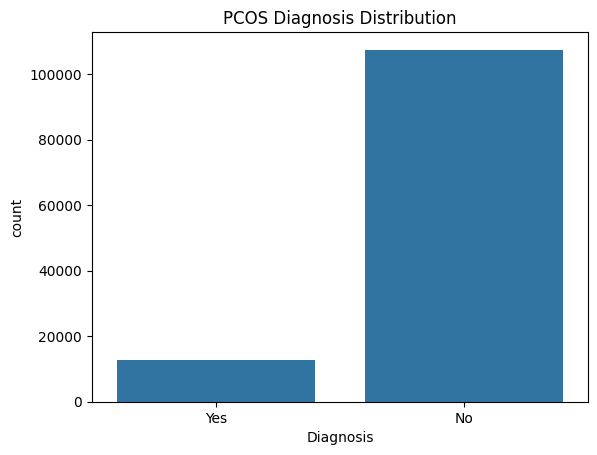

In [ ]:
sns.countplot(x='Diagnosis', data=df)
plt.title("PCOS Diagnosis Distribution")
plt.show()


data is imbalaced  (NO>>>>YES) bc  of this model can become bised toward majority and ignore minority classes , class weights going to be used to deal with this

Index(['Country', 'BMI', 'Menstrual Regularity', 'Hirsutism', 'Acne Severity',
       'Family History of PCOS', 'Insulin Resistance', 'Lifestyle Score',
       'Stress Levels', 'Urban/Rural', 'Socioeconomic Status',
       'Awareness of PCOS', 'Fertility Concerns', 'Ethnicity', 'Diagnosis'],
      dtype='object')


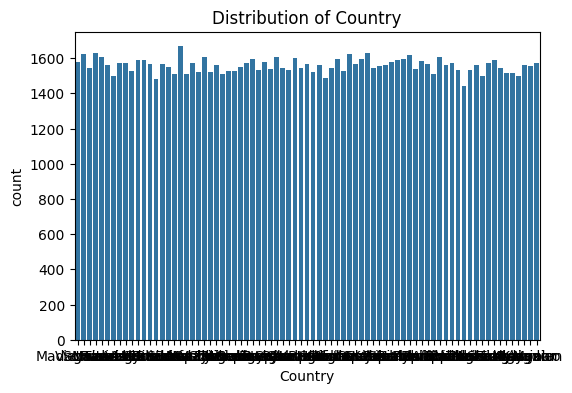

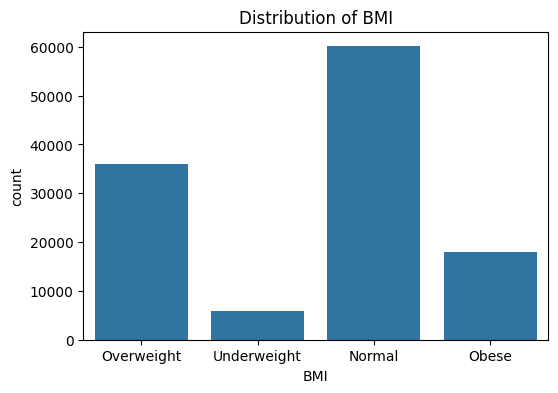

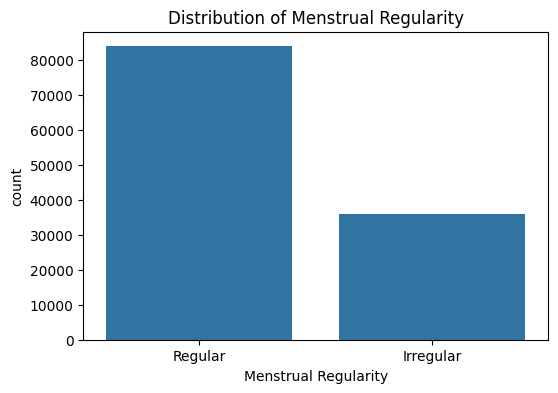

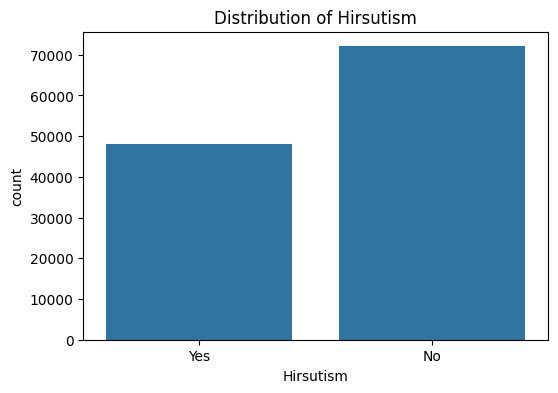

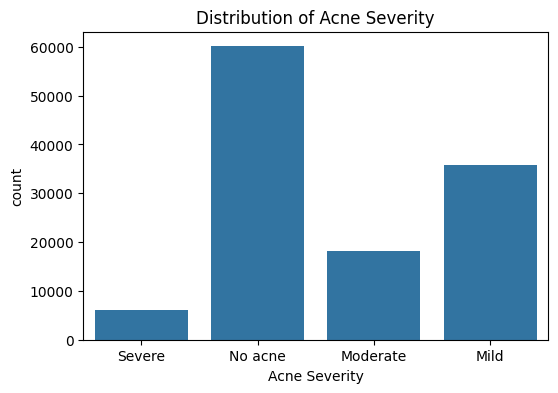

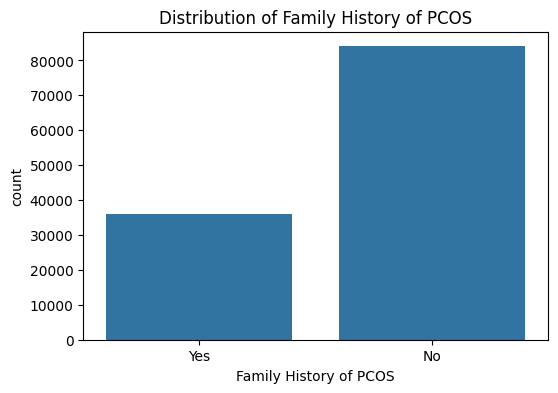

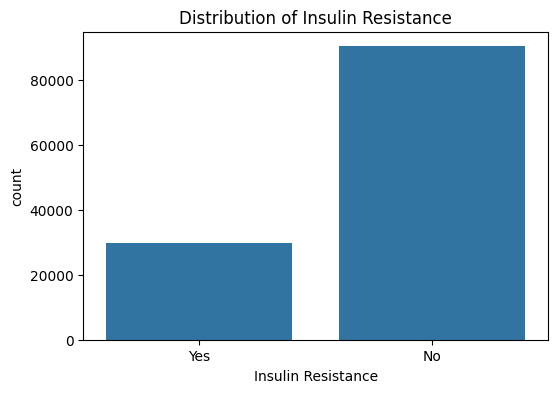

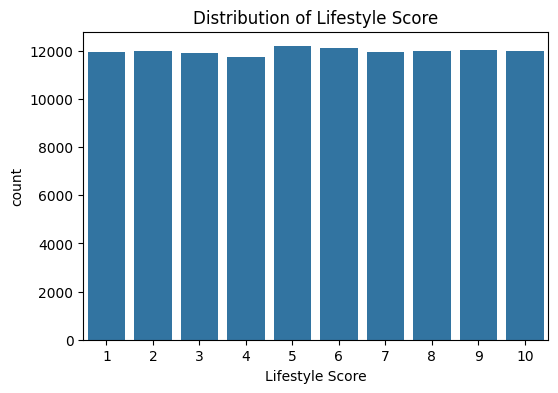

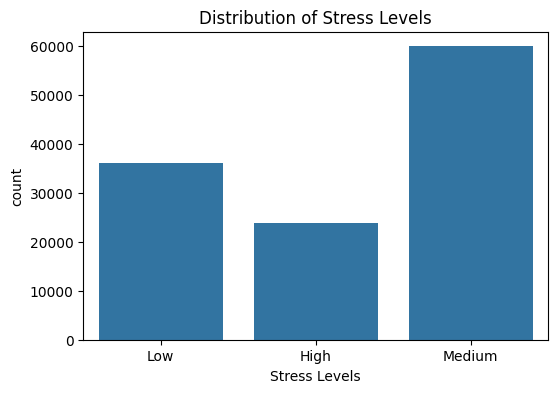

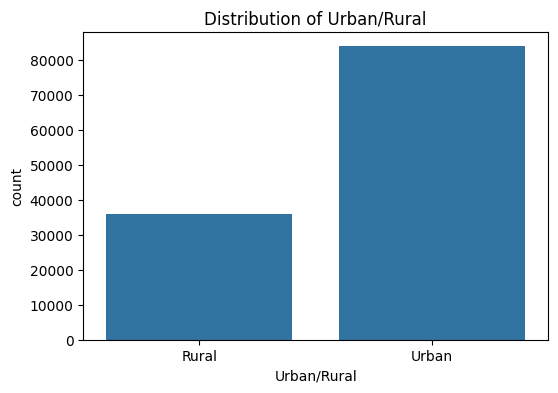

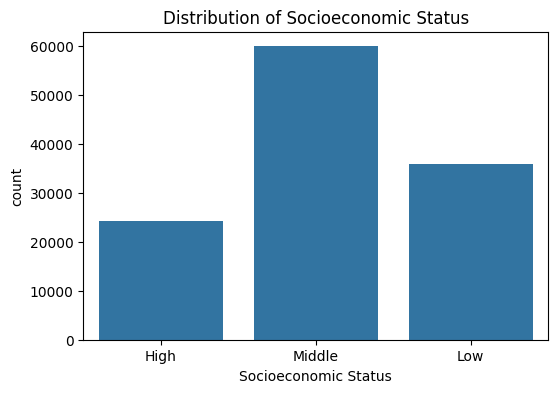

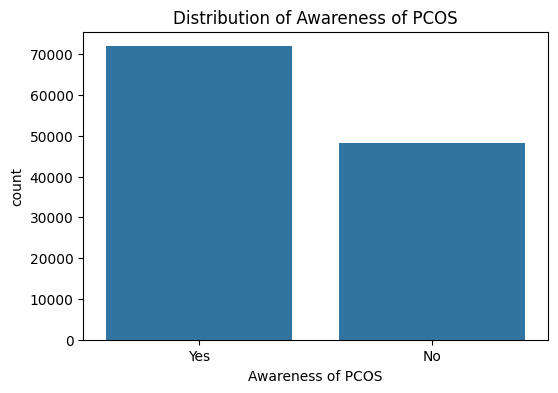

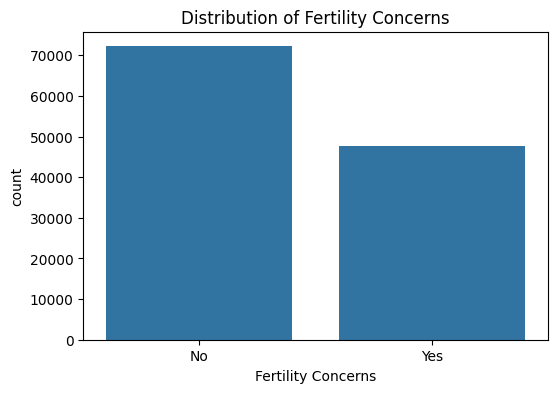

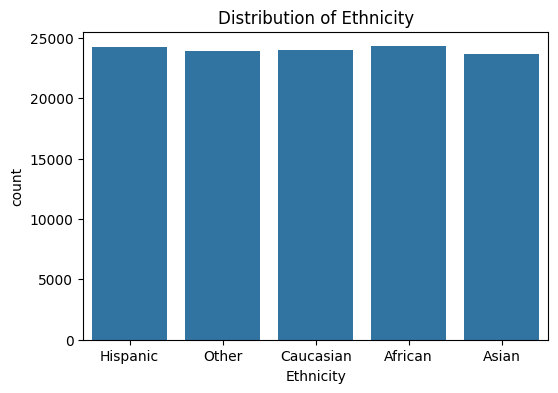

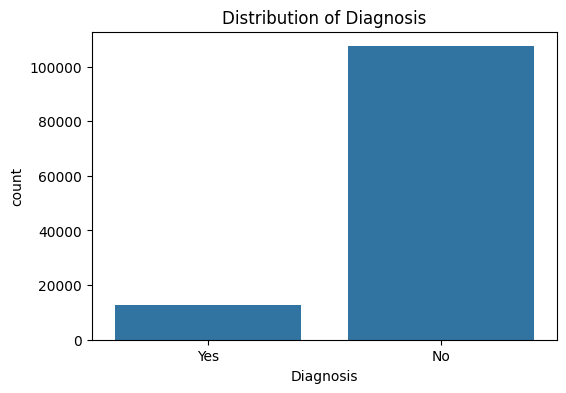

In [ ]:
#for  catagorical colms (excluding numberical colsselectinf col which has string datas )
cat_cols = df.select_dtypes(include='object').columns
print(cat_cols)
for col in cat_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(x=col, data=df)
    plt.title(f"Distribution of {col}")
    plt.show()


In [ ]:
df = df.drop(columns=['Country'])
df = df.drop(columns=['Ethnicity'])

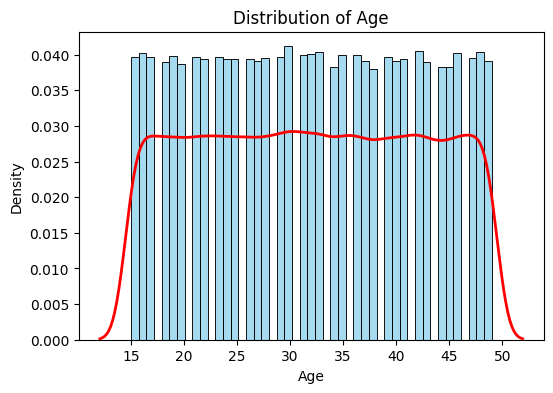

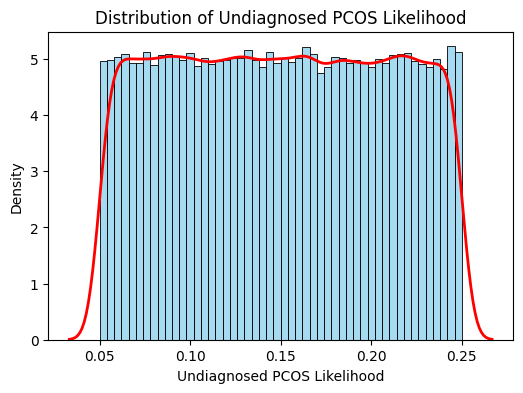

In [ ]:
ncols = df.select_dtypes(include=['int64', 'float64']).columns

for col in ncols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=False, stat='density', color='skyblue')
    sns.kdeplot(df[col], color='red', linewidth=2)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Density")
    plt.show()
# res:  uniformly distributed datas

In [ ]:
from sklearn.preprocessing import LabelEncoder
columns_to_encode = [
    'BMI', 'Menstrual Regularity', 'Hirsutism', 'Acne Severity',
    'Family History of PCOS', 'Insulin Resistance', 'Stress Levels',
    'Urban/Rural', 'Socioeconomic Status', 'Awareness of PCOS',
    'Fertility Concerns'
]
label_encoder = LabelEncoder()
for column in columns_to_encode:
    if column in df.columns:
        df[column] = label_encoder.fit_transform(df[column])

print(df.head())  # Preview the updated dataframe

   Age  BMI  Menstrual Regularity  Hirsutism  Acne Severity  \
0   26    2                     1          1              3   
1   16    3                     1          1              2   
2   41    0                     1          0              1   
3   27    0                     0          0              0   
4   26    2                     0          1              2   

   Family History of PCOS  Insulin Resistance Lifestyle Score  Stress Levels  \
0                       1                   1               2              1   
1                       0                   1               4              0   
2                       0                   0               7              2   
3                       0                   0              10              1   
4                       0                   0               7              2   

   Urban/Rural  Socioeconomic Status  Awareness of PCOS  Fertility Concerns  \
0            0                     0                  1      

In [ ]:
if 'Diagnosis' in df.columns:
    df['Diagnosis'] = df['Diagnosis'].replace({'Yes': 1, 'No': 0})

df.head()

,Age,BMI,Menstrual Regularity,Hirsutism,Acne Severity,Family History of PCOS,Insulin Resistance,Lifestyle Score,Stress Levels,Urban/Rural,Socioeconomic Status,Awareness of PCOS,Fertility Concerns,Undiagnosed PCOS Likelihood,Diagnosis
0,26,2,1,1,3,1,1,2,1,0,0,1,0,0.107938,1
1,16,3,1,1,2,0,1,4,0,0,2,1,0,0.156729,0
2,41,0,1,0,1,0,0,7,2,1,2,1,1,0.202901,0
3,27,0,0,0,0,0,0,10,1,1,0,1,0,0.073926,1
4,26,2,0,1,2,0,0,7,2,1,2,0,0,0.229266,0


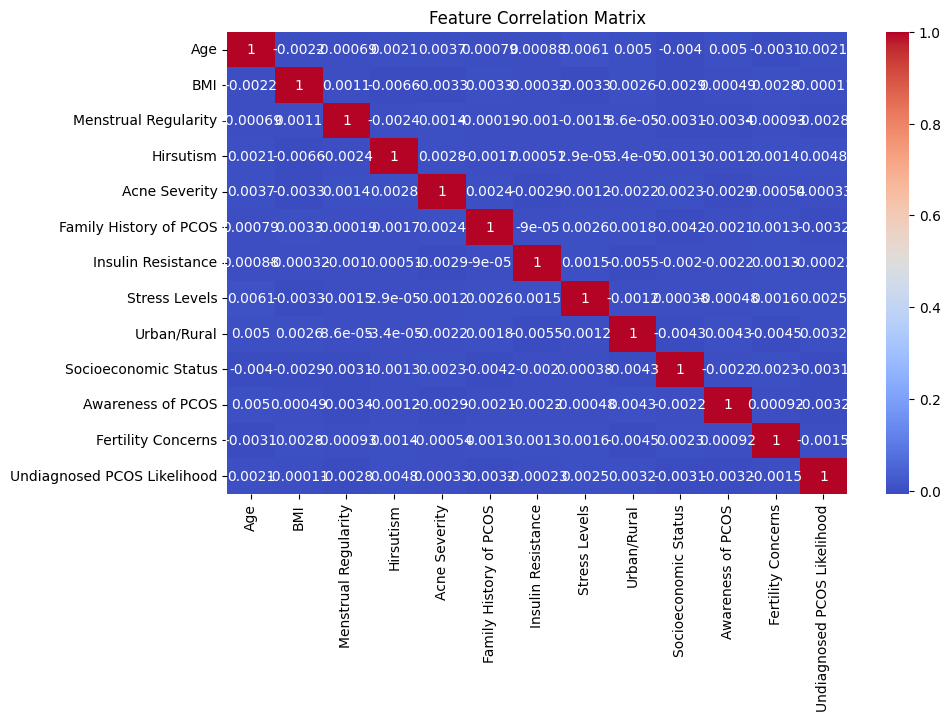

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Matrix")
plt.show()



In [ ]:
correlations = df.corr(numeric_only=True)['Diagnosis'].sort_values(ascending=False)
print(correlations)

Diagnosis                      1.000000
Socioeconomic Status           0.007914
Insulin Resistance             0.003489
BMI                            0.002574
Age                            0.001994
Urban/Rural                    0.001393
Undiagnosed PCOS Likelihood    0.001209
Hirsutism                      0.001115
Stress Levels                  0.000199
Acne Severity                 -0.000243
Family History of PCOS        -0.002051
Menstrual Regularity          -0.002272
Awareness of PCOS             -0.003138
Fertility Concerns            -0.003248
Name: Diagnosis, dtype: float64


In [ ]:
#SMOTE with clustering
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.cluster import KMeans
from imblearn.over_sampling import SMOTE
# Define X (features) and y (target)
X = df.drop('Diagnosis', axis=1)  # Features: all columns except 'Diagnosis'
y = df['Diagnosis']
# Splitting the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
print("Class distribution before SMOTE:")
print(y_train.value_counts())

Class distribution before SMOTE:
Diagnosis
0    85948
1    10052
Name: count, dtype: int64


In [ ]:
# Apply clustering to the training data
n_clusters = 7  # Number of clusters to create
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
cluster_labels = kmeans.fit_predict(X_train)

# Add cluster labels to the training data
X_train_clustered = X_train.copy()
X_train_clustered['cluster'] = cluster_labels

# Oversample within each cluster
oversampled_X = []
oversampled_y = []

for cluster in range(n_clusters):
    # Filter data for the current cluster
    cluster_data = X_train_clustered[X_train_clustered['cluster'] == cluster]
    cluster_y = y_train[cluster_data.index]

    # Drop the 'cluster' column for oversampling
    cluster_X = cluster_data.drop('cluster', axis=1)

    # Apply SMOTE to the current cluster
    smote = SMOTE(random_state=42)
    cluster_X_resampled, cluster_y_resampled = smote.fit_resample(cluster_X, cluster_y)

    # Append the resampled data
    oversampled_X.append(cluster_X_resampled)
    oversampled_y.append(cluster_y_resampled)
# Combine oversampled clusters
X_train_resampled = pd.concat(oversampled_X, axis=0)
y_train_resampled = pd.concat(oversampled_y, axis=0)

# Print class distribution after SMOTE
print("\nClass distribution after SMOTE:")
print(pd.Series(y_train_resampled).value_counts())



Class distribution after SMOTE:
Diagnosis
1    85948
0    85948
Name: count, dtype: int64


In [ ]:
# Initialize the Random Forest classifier
rf_model = RandomForestClassifier(n_estimators=200, random_state=42)

# Fit the model on the cluster-based oversampled training data
rf_model.fit(X_train_resampled, y_train_resampled)

# Predict on the test data
y_pred = rf_model.predict(X_test)



In [ ]:

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print("\nAccuracy:", accuracy)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Accuracy: 0.7881666666666667

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.87      0.88     21457
           1       0.11      0.14      0.12      2543

    accuracy                           0.79     24000
   macro avg       0.50      0.50      0.50     24000
weighted avg       0.81      0.79      0.80     24000


Confusion Matrix:
[[18569  2888]
 [ 2196   347]]


In [ ]:
from imblearn.over_sampling import BorderlineSMOTE
# Apply clustering to the training data
n_clusters = 7  # Number of clusters to create
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
cluster_labels = kmeans.fit_predict(X_train)

# Add cluster labels to the training data
X_train_clustered = X_train.copy()
X_train_clustered['cluster'] = cluster_labels

# Oversample within each cluster using Borderline SMOTE
oversampled_X = []
oversampled_y = []

for cluster in range(n_clusters):
    # Filter data for the current cluster
    cluster_data = X_train_clustered[X_train_clustered['cluster'] == cluster]
    cluster_y = y_train[cluster_data.index]

    # Drop the 'cluster' column for oversampling
    cluster_X = cluster_data.drop('cluster', axis=1)

    # Apply Borderline SMOTE to the current cluster
    borderline_smote = BorderlineSMOTE(random_state=42)
    cluster_X_resampled, cluster_y_resampled = borderline_smote.fit_resample(cluster_X, cluster_y)

    # Append the resampled data
    oversampled_X.append(cluster_X_resampled)
    oversampled_y.append(cluster_y_resampled)

In [ ]:
# Combine oversampled clusters
X_train_resampled = pd.concat(oversampled_X, axis=0)
y_train_resampled = pd.concat(oversampled_y, axis=0)

In [ ]:
# Print class distribution after Borderline SMOTE
print("\nClass distribution after Borderline SMOTE:")
print(pd.Series(y_train_resampled).value_counts())


Class distribution after Borderline SMOTE:
Diagnosis
1    85948
0    85948
Name: count, dtype: int64


In [ ]:

# Initialize the Random Forest classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)


In [ ]:
# Fit the model on the cluster-based oversampled training data
rf_model.fit(X_train_resampled, y_train_resampled)

RandomForestClassifier(random_state=42)

In [ ]:
# Predict on the test data
y_pred = rf_model.predict(X_test)

In [ ]:
# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print("\nAccuracy:", accuracy)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Accuracy: 0.8144166666666667

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.90      0.90     21457
           1       0.11      0.10      0.11      2543

    accuracy                           0.81     24000
   macro avg       0.50      0.50      0.50     24000
weighted avg       0.81      0.81      0.81     24000


Confusion Matrix:
[[19281  2176]
 [ 2278   265]]
